In [1]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
class MLP(nn.Module):
    """
    We first deal with something that's not exactly MLP, but close enough
    """
    num_units: int
    
    def setup(self):
        self.dense1 = nn.Dense(self.num_units)
        self.dense2 = nn.Dense(self.num_units)
    
    def __call__(self, x):
        f = self.dense1(x)
        # f = nn.leaky_relu(f)
        f = nn.tanh(f)
        f = self.dense2(f)
        # f = nn.tanh(f)
        # x = self.dense2(x)
        return f + x
    

class SimpleMLP(nn.Module):
    num_layers: int
    num_units: int
    num_classes: int

    def setup(self):
        # Create a list of Dense layers
        self.layers = (
            *[
                MLP(self.num_units, name=f"layer_{i:02}") for i in range(self.num_layers)
            ], 
            # MLP(self.num_units, name=f"layer_{self.num_layers-1:02}") # For now, do all the same dimensions 
        )
        
    def __call__(self, x):
        # Store input to match the notes
        self.sow('intermediates',  f'layer_{0}_output', x)
        
        # Pass the input through each layer
        for i, layer in enumerate(self.layers):
            x = layer(x)
            
            # Store input to match the notes
            self.sow('intermediates', f'layer_{i+1}_output', x)
            
        # Final layer to produce output
        # x = self.classification_layer(x)
        return x


In [3]:
key = jax.random.PRNGKey(0)
num_samples = 100
X = jax.random.uniform(key, (num_samples, 1), minval=-5.0, maxval=5.0)
y_true = 2.0 * X**2 + 3.0 * X + 5.0  # True underlying function
noise = jax.random.normal(key, (num_samples, 1)) * 1.5 # Add some noise
y = y_true # + noise

In [4]:
zeros_to_append = jnp.zeros((100, 4))

# Concatenate the original array and the zeros array along axis 1 (columns)
X = jnp.concatenate((X, zeros_to_append), axis=1)
y = jnp.concatenate((y, zeros_to_append), axis=1)

Starting training for 10000 epochs...


  0%|          | 0/10000 [00:00<?, ?it/s]

Training complete.


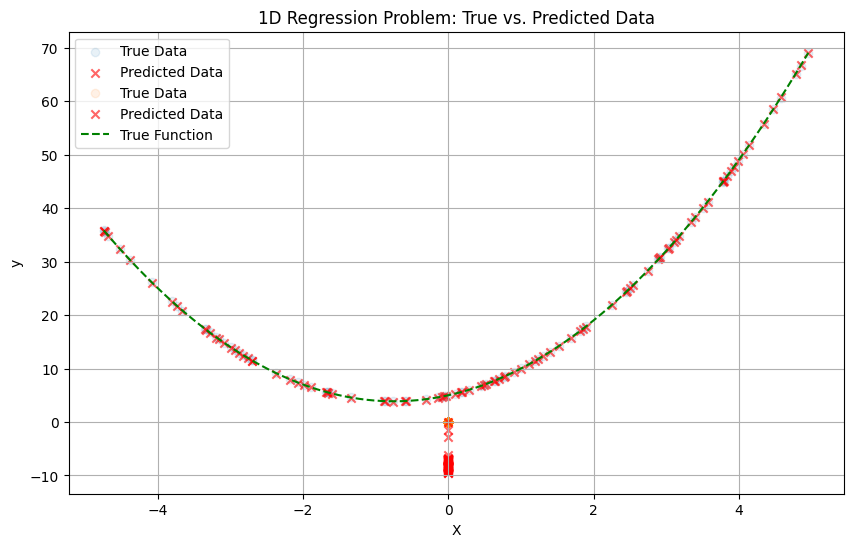

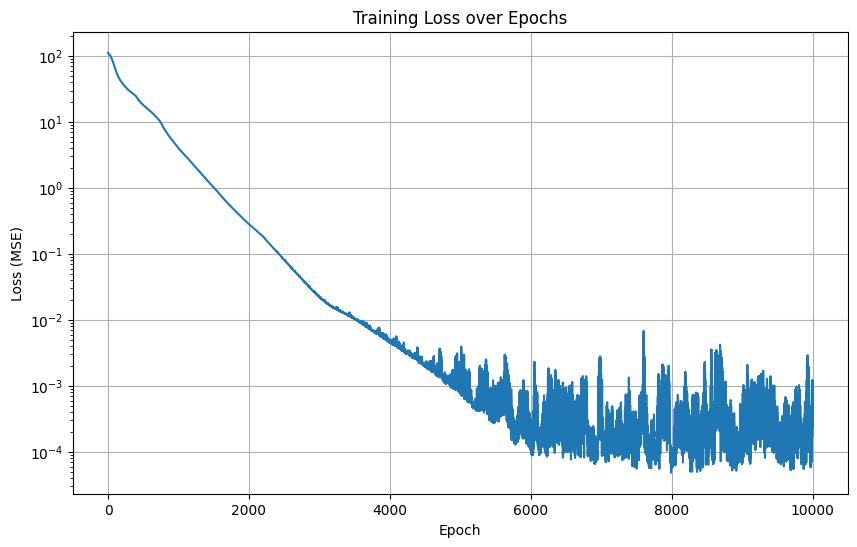

In [6]:
# 3. Define the training loop
def train_model(X_train, y_train, model_class, learning_rate, num_epochs, batch_size):
    key, params_key, dropout_key = jax.random.split(jax.random.PRNGKey(42), 3)

    # Initialize the model and parameters
    L = 10 
    model = SimpleMLP(num_layers=L, num_units=5, num_classes=5)
    # The input needs to be a dummy input for initialization, matching the shape
    params = model.init(params_key, jnp.ones((1, 5)))['params']

    # Define the optimizer
    optimizer = optax.adam(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    @jax.jit
    def train_step(state, batch_X, batch_y):
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions[:, 0] - batch_y[:, 0]))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)
        state = state.apply_gradients(grads=grads)
        return state, loss

    dataset_size = X_train.shape[0]
    num_batches = dataset_size // batch_size

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)

        avg_epoch_loss = loss / num_batches
        losses.append(avg_epoch_loss)

    print("Training complete.")
    return state, losses, model

num_epochs = 10000
batch_size = 16

# Train the model
trained_state, training_losses, model = train_model(
    X, y, SimpleMLP, learning_rate=1e-3, num_epochs=num_epochs, batch_size=batch_size
)

predicted_y = model.apply({'params': trained_state.params}, X)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y[:, 0], label='True Data', alpha=0.1)
plt.scatter(X[:, 0], predicted_y[:, 0], marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.scatter(X[:, 1], y[:, 1], label='True Data', alpha=0.1)
plt.scatter(X[:, 1], predicted_y[:, 1], marker='x', color='red', label='Predicted Data', alpha=0.6)

# Also plot the true underlying function
x_range = jnp.linspace(X[:, 0].min(), X[:, 0].max(), 100).reshape(-1, 1)
y_true_plot = 2.0 * x_range**2 + 3.0 * x_range + 5.0
plt.plot(x_range, y_true_plot, color='green', linestyle='--', label='True Function')
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Plot the training loss over epochs
plt.figure(figsize=(10, 6))
plt.semilogy(training_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()